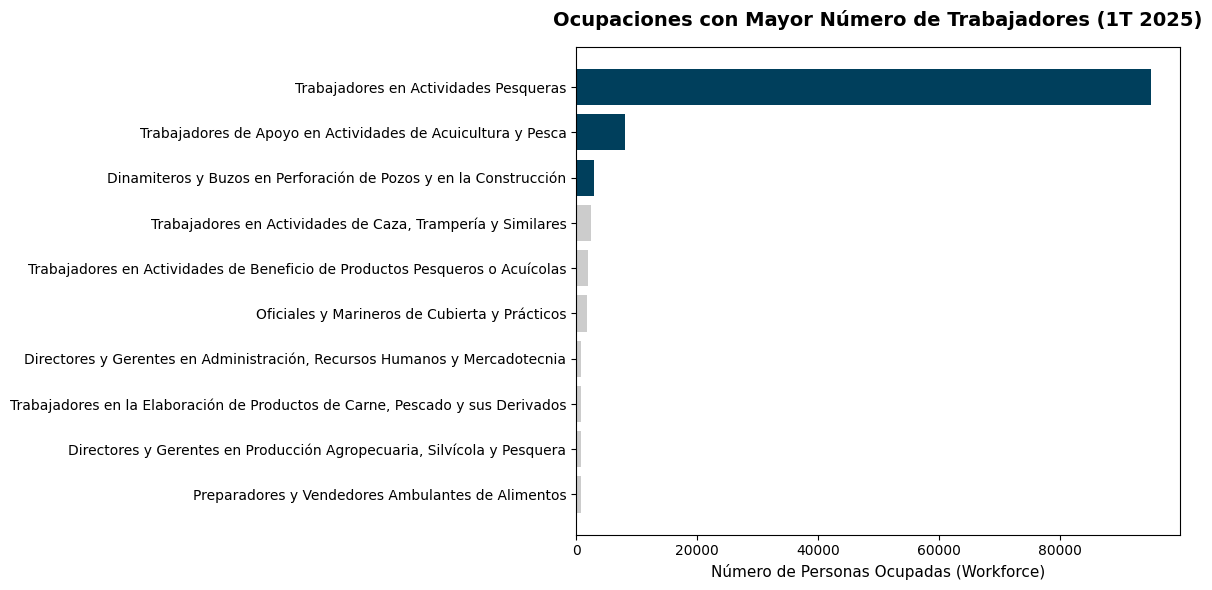

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Leer el archivo de Ocupaciones (exactamente con el nombre que subiste)
df_oc = pd.read_csv('Distribucion-poblacion-ocupada-2025-T1--Clic-en-el-grafico-para-seleccionar.csv')

# 2. Agrupar los datos para saber cuántos trabajadores hay por ocupación
df_ocupaciones = df_oc.groupby('Occupation')['Workforce'].sum().reset_index()

# 3. Ordenar de mayor a menor y sacar solo el Top 10 para no saturar la gráfica
df_top10 = df_ocupaciones.sort_values(by='Workforce', ascending=False).head(10)

# 4. LA REGLA VISUAL: Le decimos a Python cuáles 3 queremos resaltar
ocupaciones_a_resaltar = [
    'Trabajadores en Actividades Pesqueras',
    'Trabajadores de Apoyo en Actividades de Acuicultura y Pesca',
    'Dinamiteros y Buzos en Perforación de Pozos y en la Construcción'
]

# Si la ocupación está en nuestra lista, la pinta de azul fuerte; si no, de gris claro.
colores = ['#003f5c' if ocupacion in ocupaciones_a_resaltar else '#cccccc' for ocupacion in df_top10['Occupation']]

# 5. Dibujar la gráfica de barras horizontales
plt.figure(figsize=(12, 6))
plt.barh(df_top10['Occupation'], df_top10['Workforce'], color=colores)

# Invertimos el orden para que la barra más grande quede hasta arriba
plt.gca().invert_yaxis()

# 6. Títulos y ajustes visuales
plt.title('Ocupaciones con Mayor Número de Trabajadores (1T 2025)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Personas Ocupadas (Workforce)', fontsize=11)
plt.tight_layout() # Evita que los textos largos se corten

plt.show()

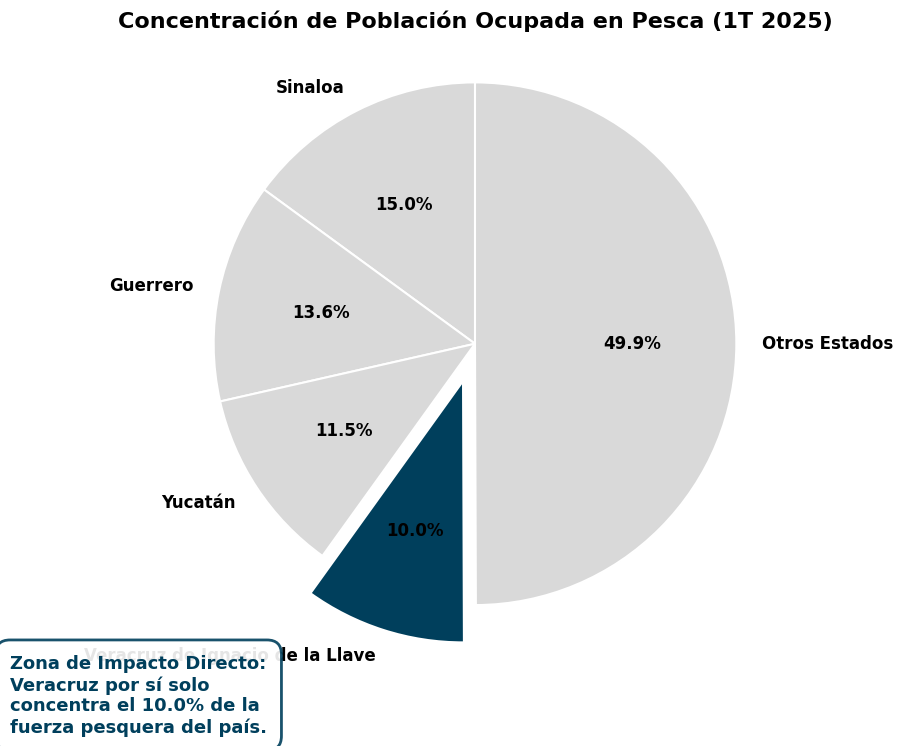

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Leer el archivo de Estados
df_st = pd.read_csv('Poblacion-ocupada-Trabajadores-en-Actividades-Pesqueras--Distribucion-de-poblacion-ocupada-segun-entidad-federativa-2025-T1.csv')
df_st = df_st[['State', 'Workforce']].dropna()

# 2. Ordenamos para ver quiénes son los verdaderos líderes nacionales
df_st = df_st.sort_values(by='Workforce', ascending=False)

# Tomamos a los 4 más grandes para dar contexto, y sumamos al resto en "Otros"
top_4 = df_st.head(4).copy()
otros_sum = df_st.iloc[4:]['Workforce'].sum()

# Unimos la tabla
df_grafica_st = pd.concat([
    top_4, 
    pd.DataFrame({'State': ['Otros Estados'], 'Workforce': [otros_sum]})
], ignore_index=True)

# 3. EL TRUCO VISUAL: Nuestro protagonista exclusivo
estado_heroe = 'Veracruz de Ignacio de la Llave'

# Solo Veracruz se separa (Explode = 0.15), los demás se quedan pegados (0)
separacion = [0.15 if estado == estado_heroe else 0 for estado in df_grafica_st['State']]

# Solo Veracruz va de azul, TODO el resto (Sinaloa, Guerrero, etc) va de gris
colores_pastel = ['#003f5c' if estado == estado_heroe else '#d9d9d9' for estado in df_grafica_st['State']]

# 4. Dibujar la gráfica de pastel
plt.figure(figsize=(10, 8))
plt.pie(df_grafica_st['Workforce'], 
        labels=df_grafica_st['State'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colores_pastel,
        explode=separacion, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}, # Líneas blancas para separar los grises
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Concentración de Población Ocupada en Pesca (1T 2025)', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')

# 5. La caja de texto exclusiva para Veracruz
total_nacional = df_st['Workforce'].sum()
suma_veracruz = df_st[df_st['State'] == estado_heroe]['Workforce'].sum()
porcentaje = (suma_veracruz / total_nacional) * 100

texto_esquina = f'Zona de Impacto Directo:\nVeracruz por sí solo\nconcentra el {porcentaje:.1f}% de la\nfuerza pesquera del país.'
estilo_caja = dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='#003f5c', alpha=0.9, linewidth=2)

plt.gca().text(-0.1, -0.1, texto_esquina, transform=plt.gca().transAxes, 
               fontsize=13, fontweight='bold', color='#003f5c', bbox=estilo_caja)

plt.show()